In [1]:
import sklearn

In [2]:
import numpy as np
from sklearn.base import BaseEstimator

class MyDummyClassifier(BaseEstimator):
    def fit(self, X, y=None):
        pass

    def predict(self, X):
        pred = np.zeros((X.shape[0], 1))
        for i in range(X.shape[0]):
            if X["Sex"].iloc[i] == 1:
                pred[i] = 0
            else:
                pred[i] = 1

        return pred

In [3]:
from sklearn.preprocessing import LabelEncoder

def fillna(df):
    df["Age"] = df["Age"].fillna(df["Age"].mean()) #inplace <= df의 값 바꾸고 바로재할당
    df["Cabin"] = df["Cabin"].fillna("N")
    df["Embarked"] = df["Embarked"].fillna("N")
    df["Fare"] = df["Fare"].fillna(0)

    return df

def drop_features(df):
    df.drop(["PassengerId", "Name", "Ticket"], axis=1, inplace=True)
    return df

In [4]:
def format_features(df):
    df["Cabin"] = df["Cabin"].str[:1]
    features = ["Cabin", "Sex", "Embarked"]
    for feature in features:
        le = LabelEncoder()
        le = le.fit(df[feature])
        df[feature] = le.transform(df[feature])

    return df

def transform_features(df):
    df = fillna(df)
    df = drop_features(df)
    df = format_features(df)

    return df


In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

titanic_df = pd.read_csv("./train.csv")
y_titanic_df = titanic_df["Survived"]
X_titanic_df = titanic_df.drop("Survived", axis=1)

X_titanic_df = transform_features(X_titanic_df)

X_train, X_test, y_train, y_test = train_test_split(X_titanic_df, y_titanic_df,
                                                    test_size = 0.2, random_state = 0)

myclf = MyDummyClassifier()
myclf.fit(X_train, y_train)

mypred = myclf.predict(X_test)

print(accuracy_score(y_test, mypred))

0.7877094972067039


In [6]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator
from sklearn.metrics import accuracy_score

import numpy as np
import pandas as pd

class MyFakeClassifier(BaseEstimator):
    def fit(self, X, y):
        pass

    def predict(self, X):
        return np.zeros((len(X), 1), dtype=bool)


digits = load_digits()

print(digits.data)
print(digits.data.shape)
print(digits.target)
print(digits.target.shape)

[[ 0.  0.  5. ...  0.  0.  0.]
 [ 0.  0.  0. ... 10.  0.  0.]
 [ 0.  0.  0. ... 16.  9.  0.]
 ...
 [ 0.  0.  1. ...  6.  0.  0.]
 [ 0.  0.  2. ... 12.  0.  0.]
 [ 0.  0. 10. ... 12.  1.  0.]]
(1797, 64)
[0 1 2 ... 8 9 8]
(1797,)


In [7]:
digits.target == 7

array([False, False, False, ..., False, False, False], shape=(1797,))

In [8]:
y = (digits.target == 7).astype(int)

X_train, X_test, y_train, y_test = train_test_split(digits.data, y, random_state=11)

In [9]:
print(y_test.shape)
print(pd.Series(y_test).value_counts())

(450,)
0    405
1     45
Name: count, dtype: int64


In [10]:
fakeclf = MyFakeClassifier()
fakeclf.fit(X_train, y_train)
fakepred = fakeclf.predict(X_test)

print(accuracy_score(y_test, fakepred))

0.9


In [11]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, fakepred)

array([[405,   0],
       [ 45,   0]])

In [12]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

print(precision_score(y_test, fakepred))
print(recall_score(y_test, fakepred))

0.0
0.0


c:\Users\KDS-11\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

def get_clf_eval(y_test, pred):
    confusion = confusion_matrix(y_test, pred)
    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)

    print(confusion)
    print(accuracy, precision, recall)

In [14]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

titanic_df = pd.read_csv("./train.csv")

y_titanic_df = titanic_df["Survived"]
X_titanic_df = titanic_df.drop("Survived", axis=1)
X_titanic_df = transform_features(X_titanic_df)

X_train, X_test, y_train, y_test = train_test_split(X_titanic_df, y_titanic_df,
                                                    test_size=0.2, random_state=11)

lr_clf = LogisticRegression(solver="liblinear")

lr_clf.fit(X_train, y_train)
pred = lr_clf.predict(X_test)

get_clf_eval(y_test, pred)

[[108  10]
 [ 14  47]]
0.8659217877094972 0.8245614035087719 0.7704918032786885


In [15]:
pred_prob = lr_clf.predict_proba(X_test)
pred = lr_clf.predict(X_test)

print(pred_prob.shape)
print(pred_prob[:3])

pred_prob_result = np.concatenate([pred_prob, pred.reshape(-1, 1)], axis = 1)
print(pred_prob_result[:3])

(179, 2)
[[0.44935227 0.55064773]
 [0.86335512 0.13664488]
 [0.86429645 0.13570355]]
[[0.44935227 0.55064773 1.        ]
 [0.86335512 0.13664488 0.        ]
 [0.86429645 0.13570355 0.        ]]


In [16]:
from sklearn.preprocessing import Binarizer

custom_threshold = 0.5

pred_prob_1 = pred_prob[:, 1].reshape(-1, 1)

binarizer = Binarizer(threshold = custom_threshold).fit(pred_prob_1)
custom_predict = binarizer.transform(pred_prob_1)

get_clf_eval(y_test, custom_predict)

[[108  10]
 [ 14  47]]
0.8659217877094972 0.8245614035087719 0.7704918032786885


In [17]:
custom_threshold = 0.4

pred_prob_1 = pred_prob[:, 1].reshape(-1, 1)

binarizer = Binarizer(threshold = custom_threshold).fit(pred_prob_1)
custom_predict = binarizer.transform(pred_prob_1)

get_clf_eval(y_test, custom_predict)

[[97 21]
 [11 50]]
0.8212290502793296 0.704225352112676 0.819672131147541


In [18]:
thresholds = [0.4, 0.45, 0.5, 0.55, 0.6]

def get_eval_by_threshold(y_test, pred_prob_c1, thresholds):
    for custom_threshold in thresholds:
        binarizer = Binarizer(threshold = custom_threshold).fit(pred_prob_c1)
        custom_predict = binarizer.transform(pred_prob_c1)
        print("임계값:", custom_threshold)
        get_clf_eval(y_test, custom_predict)

get_eval_by_threshold(y_test, pred_prob[:, 1].reshape(-1, 1), thresholds)

임계값: 0.4
[[97 21]
 [11 50]]
0.8212290502793296 0.704225352112676 0.819672131147541
임계값: 0.45
[[105  13]
 [ 13  48]]
0.8547486033519553 0.7868852459016393 0.7868852459016393
임계값: 0.5
[[108  10]
 [ 14  47]]
0.8659217877094972 0.8245614035087719 0.7704918032786885
임계값: 0.55
[[111   7]
 [ 16  45]]
0.8715083798882681 0.8653846153846154 0.7377049180327869
임계값: 0.6
[[113   5]
 [ 17  44]]
0.8770949720670391 0.8979591836734694 0.7213114754098361


In [19]:
from sklearn.metrics import precision_recall_curve

pred_prob_class1 = lr_clf.predict_proba(X_test)[:, 1] # 빅분기 실기때 쓰임.

precisions, recalls, thresholds = precision_recall_curve(y_test, pred_prob_class1)

print(thresholds.shape)
print(precisions.shape)
print(recalls.shape)

print(thresholds[:5])
print(precisions[:5])
print(recalls[:5])

thr_index = np.arange(0, thresholds.shape[0], 15)
print(thr_index)
print(np.round(thresholds[thr_index], 2))

print(np.round(precisions[thr_index], 3))
print(np.round(recalls[thr_index], 3))

(165,)
(166,)
(166,)
[0.01974988 0.06956414 0.08402808 0.08474207 0.08920161]
[0.34078212 0.34269663 0.34463277 0.34659091 0.34857143]
[1. 1. 1. 1. 1.]
[  0  15  30  45  60  75  90 105 120 135 150]
[0.02 0.11 0.13 0.14 0.16 0.24 0.32 0.45 0.62 0.73 0.87]
[0.341 0.372 0.401 0.44  0.505 0.598 0.688 0.774 0.915 0.968 0.938]
[1.    1.    0.967 0.902 0.902 0.902 0.869 0.787 0.705 0.492 0.246]


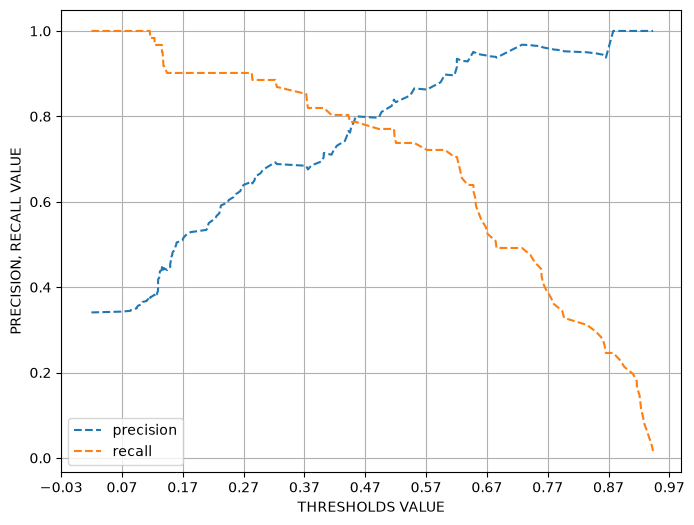

In [20]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

def precision_recall_curve_plot(y_test, pred_prob_c1):
    precisions, recalls, thresholds = precision_recall_curve(y_test, pred_prob_c1)
    plt.figure(figsize=(8, 6))
    threshold_boundary = thresholds.shape[0]
    plt.plot(thresholds, precisions[0:threshold_boundary], linestyle="--", label="precision")
    plt.plot(thresholds, recalls[0:threshold_boundary], linestyle="--", label="recall")

    start, end = plt.xlim()
    plt.xticks(np.round(np.arange(start, end, 0.1), 2))

    plt.xlabel("THRESHOLDS VALUE")
    plt.ylabel("PRECISION, RECALL VALUE")
    plt.legend()
    plt.grid()
    plt.show()

precision_recall_curve_plot(y_test, lr_clf.predict_proba(X_test)[:, 1])

In [21]:
from sklearn.metrics import f1_score

f1 = f1_score(y_test, pred)

print(f1)

0.7966101694915254


In [22]:
def get_clf_eval(y_test, pred):
    confusion = confusion_matrix(y_test, pred)
    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)

    print(confusion)
    print(accuracy, precision, recall, f1)

thresholds = [0.4, 0.45, 0.5, 0.55, 0.6]
pred_prob = lr_clf.predict_proba(X_test)

get_eval_by_threshold(y_test, pred_prob[:, 1].reshape(-1, 1), thresholds)

임계값: 0.4
[[97 21]
 [11 50]]
0.8212290502793296 0.704225352112676 0.819672131147541 0.7575757575757576
임계값: 0.45
[[105  13]
 [ 13  48]]
0.8547486033519553 0.7868852459016393 0.7868852459016393 0.7868852459016393
임계값: 0.5
[[108  10]
 [ 14  47]]
0.8659217877094972 0.8245614035087719 0.7704918032786885 0.7966101694915254
임계값: 0.55
[[111   7]
 [ 16  45]]
0.8715083798882681 0.8653846153846154 0.7377049180327869 0.7964601769911505
임계값: 0.6
[[113   5]
 [ 17  44]]
0.8770949720670391 0.8979591836734694 0.7213114754098361 0.8


In [23]:
from sklearn.metrics import roc_curve

pred_proba_class1 = lr_clf.predict_proba(X_test)[:, 1]

fprs, tprs, thresholds = roc_curve(y_test, pred_proba_class1)

thr_index = np.arange(1, thresholds.shape[0], 5)

print(thr_index)
print(np.round(thresholds[thr_index], 2))

print(np.round(fprs[thr_index], 3))
print(np.round(tprs[thr_index], 3))

[ 1  6 11 16 21 26 31 36 41 46]
[0.94 0.73 0.62 0.52 0.44 0.28 0.15 0.14 0.13 0.12]
[0.    0.008 0.025 0.076 0.127 0.254 0.576 0.61  0.746 0.847]
[0.016 0.492 0.705 0.738 0.803 0.885 0.902 0.951 0.967 1.   ]


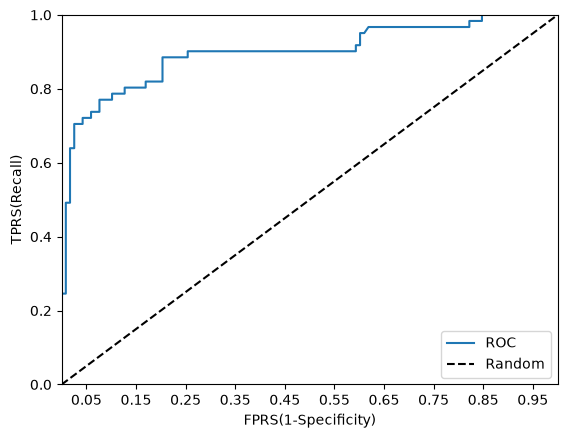

In [24]:
def roc_curve_plot(y_test, pred_proba_c1):
    fprs, tprs, thresholds = roc_curve(y_test, pred_proba_c1)

    plt.plot(fprs, tprs, label="ROC")
    plt.plot([0, 1], [0, 1], "k--", label="Random")

    start, end = plt.xlim()
    plt.xticks(np.round(np.arange(start, end, 0.1), 2))
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.xlabel("FPRS(1-Specificity)")
    plt.ylabel("TPRS(Recall)")
    plt.legend()
    plt.show()

roc_curve_plot(y_test, lr_clf.predict_proba(X_test)[:, 1])

In [25]:
from sklearn.metrics import roc_auc_score

pred_proba = lr_clf.predict_proba(X_test)[:, 1]
roc_auc_score = roc_auc_score(y_test, pred_proba)
print(roc_auc_score)

0.8986524034454015
